<a href="https://colab.research.google.com/github/carlosprr29/ai-progetto-spagnoli/blob/main/notebooks/01_3_Exploratory_Data_Analysis_FUSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================================
# PHASE: Dataset Fusion & Final Exploratory Data Analysis (EDA)
# =================================================================

# 1. INSTALLATION AND LOADING OF LIBRARIES
# -----------------------------------------------------------------
# We install datasets in case it's not in the environment
!git clone https://github.com/carlosprr29/ai-progetto-spagnoli.git
%cd ai-progetto-spagnoli
!pip install -r requirements.txt

import sys
import warnings
from google.colab import drive
drive.mount('/content/drive')

# Add the project path to find 'src'
PROJECT_PATH = '/content/drive/MyDrive/Project_IA'
sys.path.append(PROJECT_PATH)

# Import the specific functions from our data_loader.py
from src.data_loader import create_fusion_dataset
from src.eda_utils import plot_class_balance, generate_cloud, analyse_term, plot_text_length

warnings.filterwarnings('ignore')


In [ ]:
# 2. FINAL FUSION AND EXPORT
# -----------------------------------------------------------------
# Merging both dataframes into a unified corpus
df_fusion = create_fusion_dataset(PROJECT_PATH)

In [ ]:
# 3. GLOBAL CLASS BALANCE ANALYSIS
# -----------------------------------------------------------------
plot_class_balance(df_fusion)

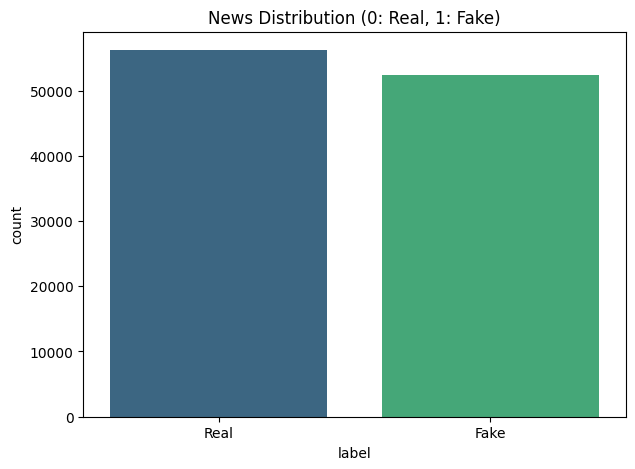

In [ ]:
# 4. CONTENT EXPLORATION (Sampling)
# -----------------------------------------------------------------
print("\n Displaying 50 random news items from the dataset:")
display(df_fusion[['title', 'label']].sample(50))

The sample of fused data demonstrates a clear linguistic divergence between the two classes. Real news (Label 0) consistently employs a factual, report-style tone, often mentioning specific institutional sources (e.g., 'government source', 'NYT', 'The News Outlet'). In contrast, Fake news (Label 1) relies heavily on emotional triggers, hyperbole, and informal exclamations (e.g., 'BOOM!', 'UNREAL!', 'WOW!', 'Numbskull'). This confirms that the dataset contains strong stylistic markers that a transformer model like BERT can exploit to distinguish between classes beyond the factual content

In [ ]:
# 5. TEXT LENGTH ANALYSIS (Checking for Bias Dilution)
# -----------------------------------------------------------------
plot_text_length(df_fusion)

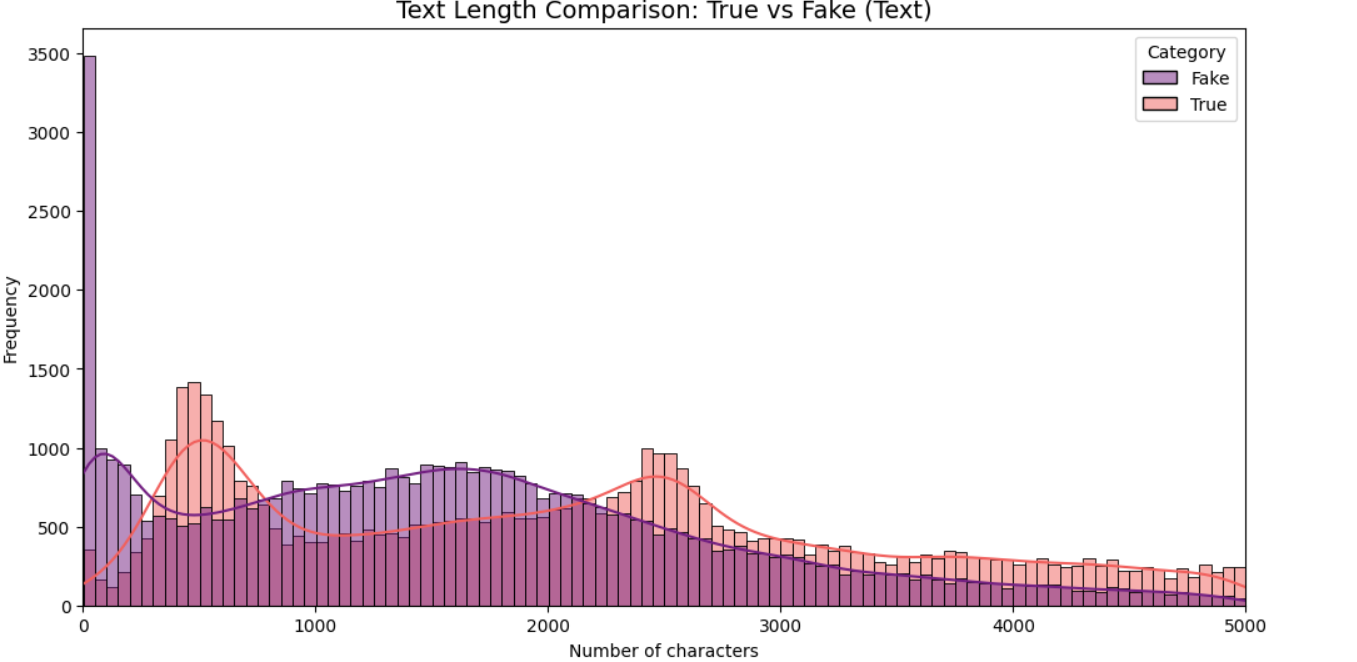

In [ ]:
# 6. FINAL WORDCLOUDS (Visual Validation)
# -----------------------------------------------------------------
generate_cloud(df_fusion,
               news_label=0,
               text_col='text',
               colour_map='Greens',
               graph_title='Most common words in REAL headlines')

generate_cloud(df_fusion,
               news_label=1,
               text_col='text',
               colour_map='Reds',
               graph_title='Most common words in FAKE headlines')



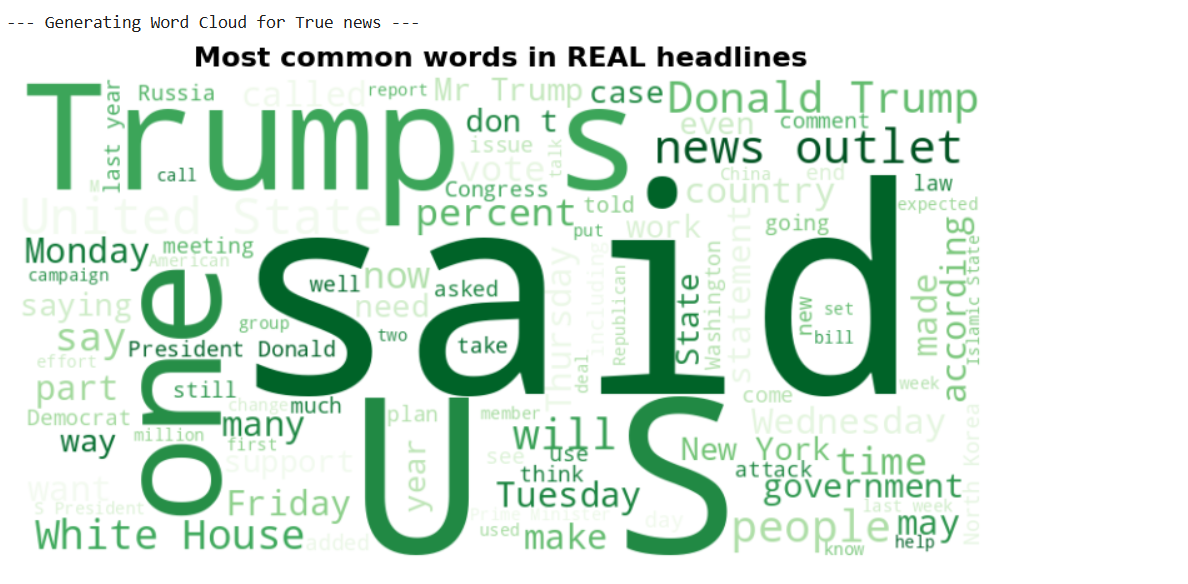

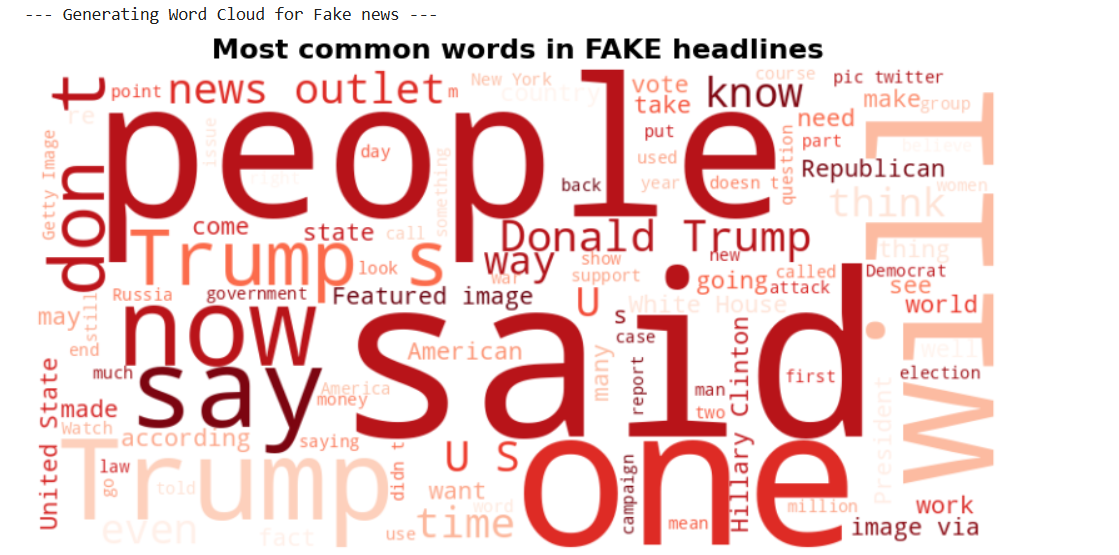

In [ ]:
# 7. FUSION BIAS TRACKER (Keyword Dilution)
# -----------------------------------------------------------------

analyse_term(df_fusion,"Trump")
analyse_term(df_fusion,"said")
analyse_term(df_fusion,"one")
analyse_term(df_fusion,"people")
analyse_term(df_fusion,"now")
analyse_term(df_fusion,"Donald Trump")

Term 'Trump' found in 31875 titles.
   ↳ Distribution: {'Fake': '56.19%', 'True': '43.81%'}

Term 'said' found in 467 titles.
   ↳ Distribution: {'Fake': '82.66%', 'True': '17.34%'}

Term 'one' found in 5120 titles.
   ↳ Distribution: {'Fake': '63.16%', 'True': '36.84%'}

Term 'people' found in 1374 titles.
   ↳ Distribution: {'Fake': '76.13%', 'True': '23.87%'}

Term 'now' found in 1894 titles.
   ↳ Distribution: {'Fake': '75.34%', 'True': '24.66%'}

Term 'Donald Trump' found in 2678 titles.
   ↳ Distribution: {'Fake': '65.53%', 'True': '34.47%'}

In [ ]:
# 9. EXPORT FOR TRAINING
# -----------------------------------------------------------------
# Extracting 50 samples for manual QC
df_fusion.sample(n=50, random_state=42).to_csv("/content/drive/MyDrive/Project_IA/data/fusion_samples_check.csv", index=False)

# Save the full fused dataset
df_fusion.to_csv("/content/drive/MyDrive/Project_IA/data/final_fused_dataset.csv", index=False)
print(" Final Fused Dataset saved successfully for training.")

# Conclusion
The EDA of the fused dataset identifies three key markers of misinformation: emotional/informal language (e.g., 'People', 'Now'), structural bias (the word 'Video' correlates 99% with Fake News), and political entity bias (Hillary/Obama appearing almost exclusively in fake content). While these patterns make the classes highly separable, they also risk model 'leakage'. Therefore, rigorous preprocessing is mandatory to ensure BERT learns semantic meaning rather than superficial lexical shortcuts